## import libraries:

In [274]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

## EDA :

In [275]:
import pandas as pd
movies = pd.read_csv(r"D:\ig\ig project\movies.csv")
print(movies.head().to_string(index=False))

 movieId                              title                                      genres
       1                   Toy Story (1995) Adventure|Animation|Children|Comedy|Fantasy
       2                     Jumanji (1995)                  Adventure|Children|Fantasy
       3            Grumpier Old Men (1995)                              Comedy|Romance
       4           Waiting to Exhale (1995)                        Comedy|Drama|Romance
       5 Father of the Bride Part II (1995)                                      Comedy


In [276]:
ratings = pd.read_csv(r"D:\ig\ig project\ratings.csv")
print(ratings.head())

   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931


In [277]:
print(movies.shape)
print(movies.isnull().sum())
print(movies.duplicated().sum())


(9742, 3)
movieId    0
title      0
genres     0
dtype: int64
0


In [278]:
print(ratings.shape)
print(ratings.isnull().sum())
print(ratings.duplicated().sum())

(100836, 4)
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64
0


## VISUALIZATION:

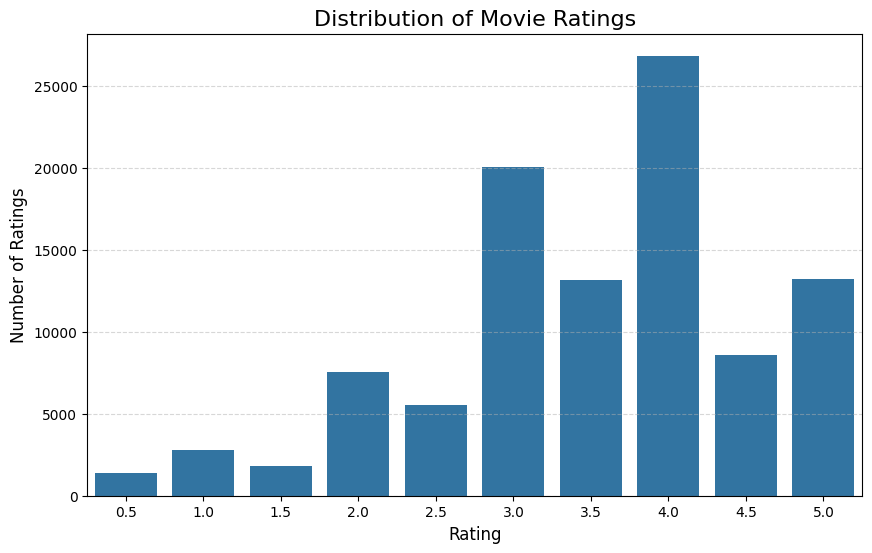

In [279]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.countplot(
    x='rating',
    data=ratings,
    order=sorted(ratings['rating'].unique())
)

plt.title("Distribution of Movie Ratings", fontsize=16)

plt.xlabel("Rating", fontsize=12)
plt.ylabel("Number of Ratings", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

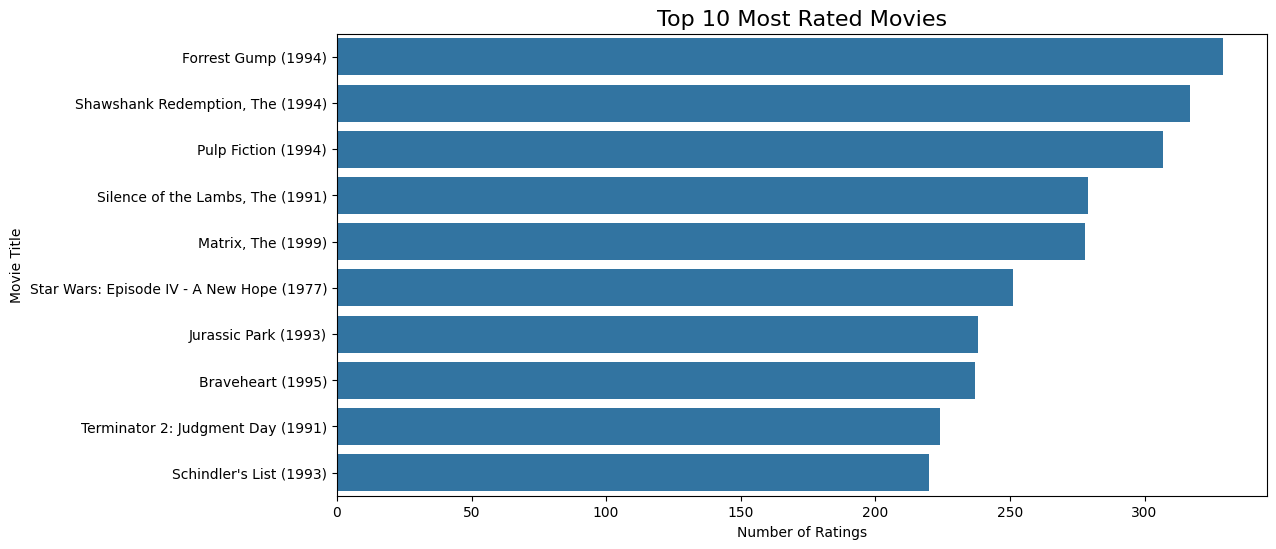

In [280]:
movie_rating_counts = ratings.groupby('movieId')['rating'].count()

top_movies = movie_rating_counts.sort_values(
    ascending=False
).head(10)

top_movies_df = pd.DataFrame(top_movies).reset_index()

top_movies_df = top_movies_df.merge(
    movies[['movieId', 'title']],
    on='movieId'
)

plt.figure(figsize=(12,6))

sns.barplot(
    x='rating',
    y='title',
    data=top_movies_df
)

plt.title("Top 10 Most Rated Movies", fontsize=16)

plt.xlabel("Number of Ratings")
plt.ylabel("Movie Title")

plt.show()

## CONTENT BASED :

# Ensure All ARE Strings And Replace Nan With "Unkown"

In [281]:
movies["genres"] = movies["genres"].fillna("UNKOWN").astype(str)


## Convert Text to Numerical Features (TF-IDF)

In [282]:
tfidf = TfidfVectorizer(stop_words="english")
tfidf_matrix = tfidf.fit_transform(movies["genres"])

## Compute Similarity Between Movies

In [283]:
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

## Map Movie Titles to Index

In [284]:
title_to_index = pd.Series(movies.index, index=movies["title"]).drop_duplicates()

## Recommendation Function

In [285]:
def content_recommend(title, top_n=10):
    if title not in title_to_index:
        return []

    idx = title_to_index[title]
    sim_scores = list(enumerate(cosine_sim[idx]))

    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:top_n+1]
    movie_idx = [i[0] for i in sim_scores]

    results = movies.iloc[movie_idx][["movieId", "title"]]

    return results.to_dict("records")


## collaborative

## Train / Test Split

In [286]:
train, test = train_test_split(ratings, test_size=0.2, random_state=42)

## User–Item Matrix

In [287]:
user_item_matrix = train.pivot_table(
    index="userId",
    columns="movieId",
    values="rating"
).fillna(0)

## Apply SVD

In [288]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=50, random_state=42)
matrix_svd = svd.fit_transform(user_item_matrix)
reconstructed = np.dot(matrix_svd, svd.components_)

## Map userId to index

In [289]:
user_index_map = {u: i for i, u in enumerate(user_item_matrix.index)}

## predict Function

In [290]:
def collab_predict(user_id, movie_id):
    if user_id not in user_index_map:
        return 4.0  

    user_idx = user_index_map[user_id]

    if movie_id not in user_item_matrix.columns:
        return 4.0

    movie_idx = list(user_item_matrix.columns).index(movie_id)

    return reconstructed[user_idx][movie_idx]


def collab_recommend(user_id, top_n=10):
    if user_id not in user_index_map:
        return []

    user_idx = user_index_map[user_id]
    scores = reconstructed[user_idx]

    top_indices = np.argsort(scores)[::-1][:top_n]

    results = movies.iloc[top_indices][["movieId", "title"]]

    return results.to_dict("records")

    return movie_ids

## Hybrid 

In [291]:
def hybrid_recommend(user_id, title, top_n=10, w1=0.5, w2=0.5):

    content_movies = content_recommend(title, top_n * 2)
    collab_movies = collab_recommend(user_id, top_n * 2)

    scores = {}


    for i, m in enumerate(content_movies):
        movie_id = m["movieId"]
        scores[movie_id] = scores.get(movie_id, 0) + w1 / (i + 1)
    
    for i, m in enumerate(collab_movies):
        movie_id = m["movieId"]
        scores[movie_id] = scores.get(movie_id, 0) + w2 / (i + 1)
   
    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    movie_ids = [m[0] for m in ranked[:top_n]]
    result = movies[movies["movieId"].isin(movie_ids)][["movieId", "title"]]

    return result.to_dict("records")


## Evaluation

In [292]:
def evaluate():
    y_true = []
    y_pred = []

    sample = test.sample(min(5000, len(test)), random_state=42)

    for _, row in sample.iterrows():
        user = row["userId"]
        movie = row["movieId"]
        true = row["rating"]

        pred = collab_predict(user, movie)

        y_true.append(true)
        y_pred.append(pred)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    return rmse, mae

## Test

In [293]:
print(content_recommend("Toy Story (1995)", 10))


[{'movieId': 2294, 'title': 'Antz (1998)'}, {'movieId': 3114, 'title': 'Toy Story 2 (1999)'}, {'movieId': 3754, 'title': 'Adventures of Rocky and Bullwinkle, The (2000)'}, {'movieId': 4016, 'title': "Emperor's New Groove, The (2000)"}, {'movieId': 4886, 'title': 'Monsters, Inc. (2001)'}, {'movieId': 45074, 'title': 'Wild, The (2006)'}, {'movieId': 53121, 'title': 'Shrek the Third (2007)'}, {'movieId': 65577, 'title': 'Tale of Despereaux, The (2008)'}, {'movieId': 91355, 'title': 'Asterix and the Vikings (Astérix et les Vikings) (2006)'}, {'movieId': 103755, 'title': 'Turbo (2013)'}]


In [294]:
print(collab_recommend(1, 10))



[{'movieId': 1151, 'title': 'Lesson Faust (1994)'}, {'movieId': 1178, 'title': 'Paths of Glory (1957)'}, {'movieId': 1263, 'title': 'Deer Hunter, The (1978)'}, {'movieId': 2502, 'title': 'Office Space (1999)'}, {'movieId': 1982, 'title': 'Halloween (1978)'}, {'movieId': 256, 'title': 'Junior (1994)'}, {'movieId': 569, 'title': 'Little Big League (1994)'}, {'movieId': 588, 'title': 'Aladdin (1992)'}, {'movieId': 1192, 'title': 'Paris Is Burning (1990)'}, {'movieId': 1013, 'title': 'Parent Trap, The (1961)'}]


In [295]:
print(hybrid_recommend(1, "Toy Story (1995)", 10))

[{'movieId': 1151, 'title': 'Lesson Faust (1994)'}, {'movieId': 1178, 'title': 'Paths of Glory (1957)'}, {'movieId': 1263, 'title': 'Deer Hunter, The (1978)'}, {'movieId': 1982, 'title': 'Halloween (1978)'}, {'movieId': 2294, 'title': 'Antz (1998)'}, {'movieId': 2502, 'title': 'Office Space (1999)'}, {'movieId': 3114, 'title': 'Toy Story 2 (1999)'}, {'movieId': 3754, 'title': 'Adventures of Rocky and Bullwinkle, The (2000)'}, {'movieId': 4016, 'title': "Emperor's New Groove, The (2000)"}, {'movieId': 4886, 'title': 'Monsters, Inc. (2001)'}]
